# Three channel data creation

> Creating a three channel dataset for better training

In [1]:
#| default_exp three_channel_with_diff.preprocessing.save_image

In [2]:
#| hide
%load_ext autoreload
%autoreload 2


In [3]:
#| hide
from nbdev.showdoc import *
from pathlib import Path
from fastcore.all import *
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [4]:
#| export
import torch

In [5]:
#| export
from cv_tools.core import *

In [6]:
#| exporti
from new_test.patching.edge_segmentation_model import *
from new_test.patching.inference_batch_image import *

In [7]:
#| export
def foo(): pass

In [8]:
DATA_PATH = Path(r'/home/hasan/workspace/projects/data/ET')
im1_path = Path(DATA_PATH, 'main_im1_cropped')
im2_path = Path(DATA_PATH, 'main_im2_cropped')
model_fn = Path(r'/home/hasan/workspace/projects/data/ET/models/model_20260115_142602_lr_0.0002_epochs_200.pth_best_val_0.8401_epoch_129.pth')
model_fn = Path(r'/home/hasan/workspace/projects/data/ET/models/epoch_106_val_dice_0.9557_05_08_27.pt')
DATA_PATH.ls(),im1_path.ls(),im2_path.ls()

([Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped'), Path('/home/hasan/workspace/projects/data/ET/main_im2_cropped'), Path('/home/hasan/workspace/projects/data/ET/models'), Path('/home/hasan/workspace/projects/data/ET/main_pr_cropped')],
 (#5280) [Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060422382784_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421493033_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060423533424_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421010930_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060423104875_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421245237_Out_138_Missing Lead_im

In [9]:
im_pairs = [(Path(i).name, Path(i).name.replace('image2', 'image1')) for i in im2_path.ls()]

In [10]:
im1_path.ls(), im2_path.ls()

((#5280) [Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060422382784_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421493033_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060423533424_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421010930_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060423104875_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060421245237_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060418434165_Out_138_Missing Lead_image1.png'), Path('/home/hasan/workspace/projects/data/ET/main_im1_cropped/VFV4.9.0.3_2025060420313476_Out_138_Missing Lead_imag

In [11]:
im2_name, im1_name = im_pairs[0]
im1_name, im2_name

('VFV4.9.0.3_2025060419170647_Out_138_Missing Lead_image1.png',
 'VFV4.9.0.3_2025060419170647_Out_138_Missing Lead_image2.png')

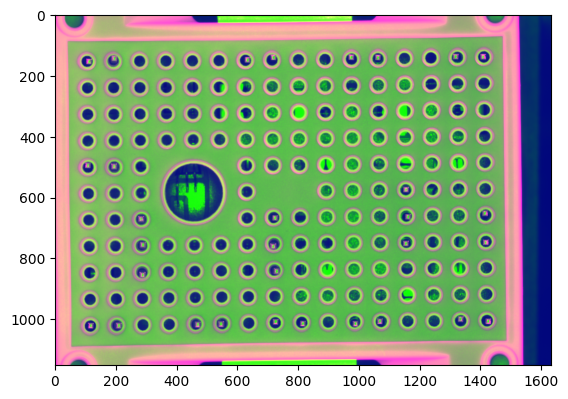

In [12]:
im1_img = cv2.imread(Path(im1_path, im1_name).as_posix(), cv2.IMREAD_GRAYSCALE)
im2_img = cv2.imread(Path(im2_path, im2_name).as_posix(), cv2.IMREAD_GRAYSCALE)
im1_img.shape, im2_img.shape
im1_img_ = im1_img.astype(np.float32)/255.0
im2_img_ = im2_img.astype(np.float32)/255.0
im1_img_.shape, im2_img_.shape
diff_ch = (im1_img_ - im2_img_ + 1.0)/2.0
thr_ch = np.stack([im1_img_, im2_img_, diff_ch], axis=-1)

plt.imshow(thr_ch)












In [13]:
#| export
def build_three_channel_image(im1_path, im2_path):
    im1_img = cv2.imread(Path(im1_path, im1_name).as_posix(), cv2.IMREAD_GRAYSCALE)
    im2_img = cv2.imread(Path(im2_path, im2_name).as_posix(), cv2.IMREAD_GRAYSCALE)
    im1_img_ = im1_img.astype(np.float32)/255.0
    im2_img_ = im2_img.astype(np.float32)/255.0
    diff_ch = (im1_img_ - im2_img_ + 1.0)/2.0
    thr_ch = np.stack([im1_img_, im2_img_, diff_ch], axis=-1)
    return thr_ch

In [14]:
#| export
from itertools import product

In [15]:
H,W,c = thr_ch.shape
H,W,c

(1152, 1632, 3)

In [16]:
PATCH_SIZE = 400
STRIDE = 128
all_patches = []
for r, c in product(
    range(0, H, STRIDE),
    range(0, W, STRIDE),
    ):
    patch = np.zeros((PATCH_SIZE, PATCH_SIZE, thr_ch.shape[-1]), dtype=thr_ch.dtype)
    r_end = min(r+PATCH_SIZE,H)
    c_end = min(c+PATCH_SIZE,W)
    patch[:r_end-r, :c_end-c, :] = thr_ch[r:r_end, c:c_end, :]
    all_patches.append(patch)

In [17]:
from cv_tools.core import *

In [18]:
#| export
def extract_patches(
    im, # Opencv image 
    patch_size:int, # Patch size
    stride:int, # Stride
    ):
    "Extract patches from an image"
    H,W,c = im.shape
    all_patches = []
    for r, c in product(
        range(0, H, stride),
        range(0, W, stride),
    ):
        patch = np.zeros((patch_size, patch_size, im.shape[-1]), dtype=im.dtype)
        r_end = min(r+patch_size,H)
        c_end = min(c+patch_size,W)
        patch[:r_end-r, :c_end-c, :] = im[r:r_end, c:c_end, :]
        all_patches.append(patch)
    return all_patches


In [19]:
assert len(extract_patches(thr_ch, PATCH_SIZE, STRIDE)) == 117


In [20]:
pin_counts_ = {
    '149':29,
    '152':34,
    '153':23,
    '150':22, 
    '68':33,
    '138':31,
    '18':35
    }

In [21]:
Counter(im2_path.ls().map(lambda x: extract_type_from_filename(Path(x).name)))

NameError: name 'Counter' is not defined

In [22]:
type_dict = {i[0]:extract_type_from_filename(i[0]) for i in im_pairs}
type_dict

{'VFV4.9.0.3_2025060419170647_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060420201306_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060419152023_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060419502116_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060420302618_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060422222770_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060419353829_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060423171145_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060421273609_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060423274514_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060421522138_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060420210596_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060420385676_Out_138_Missing Lead_image2.png': '138',
 'VFV4.9.0.3_2025060421104252_Out_138_Missing Lead_image2.png': '138',
 'VFV4

In [23]:
rec18 = [k for k,v in type_dict.items() if v == "18"]
rec138 = [k for k,v in type_dict.items() if v == "138"]
rec68 = [k for k,v in type_dict.items() if v == "68"]

In [24]:
rec18_pairs = [i for i in im_pairs if i[0] in rec18]
rec138_pairs = [i for i in im_pairs if i[0] in rec138]
rec68_pairs = [i for i in im_pairs if i[0] in rec68]
sm_pairs = rec18_pairs[0]
im2_name, im1_name = sm_pairs
im1_name

'VFV4.9.0.3_2025060314535059_Out_18_Missing Lead_image1.png'

In [25]:
model_fn

Path('/home/hasan/workspace/projects/data/ET/models/epoch_106_val_dice_0.9557_05_08_27.pt')

In [26]:
two_img_model = load_whole_pipeline_model(
    model_path=model_fn,
    in_channels=1,
    out_channels=1,
    tile_size=256,
	pred_threshold=0.5,
	dilation_iteration_rev=2,
	dilation_iteration=2,
	map_location='cuda',
	dropout_p=0.1,
	convert_to_onnx=False,
	opset_version=12,
	input_shape=(1,2,1152,1632),
	edge_model=True, # or False
	onnx_path=Path('ETWAR_PatchLoetPinv00.onnx')

)

CUDA available: True
 ####################################################################################################
Loading model from /home/hasan/workspace/projects/data/ET/models/epoch_106_val_dice_0.9557_05_08_27.pt using cuda as map location
 ####################################################################################################


In [27]:
im1_img = cv2.imread(Path(im1_path, im1_name).as_posix(), cv2.IMREAD_GRAYSCALE)
im2_img = cv2.imread(Path(im2_path, im2_name).as_posix(), cv2.IMREAD_GRAYSCALE)
comb_img = process_image_im1_im2_j(im1=im1_img, im2=im2_img)
#show_(im1_img)

In [28]:
with torch.no_grad():
	two_img_model_pred = two_img_model(comb_img)

 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40


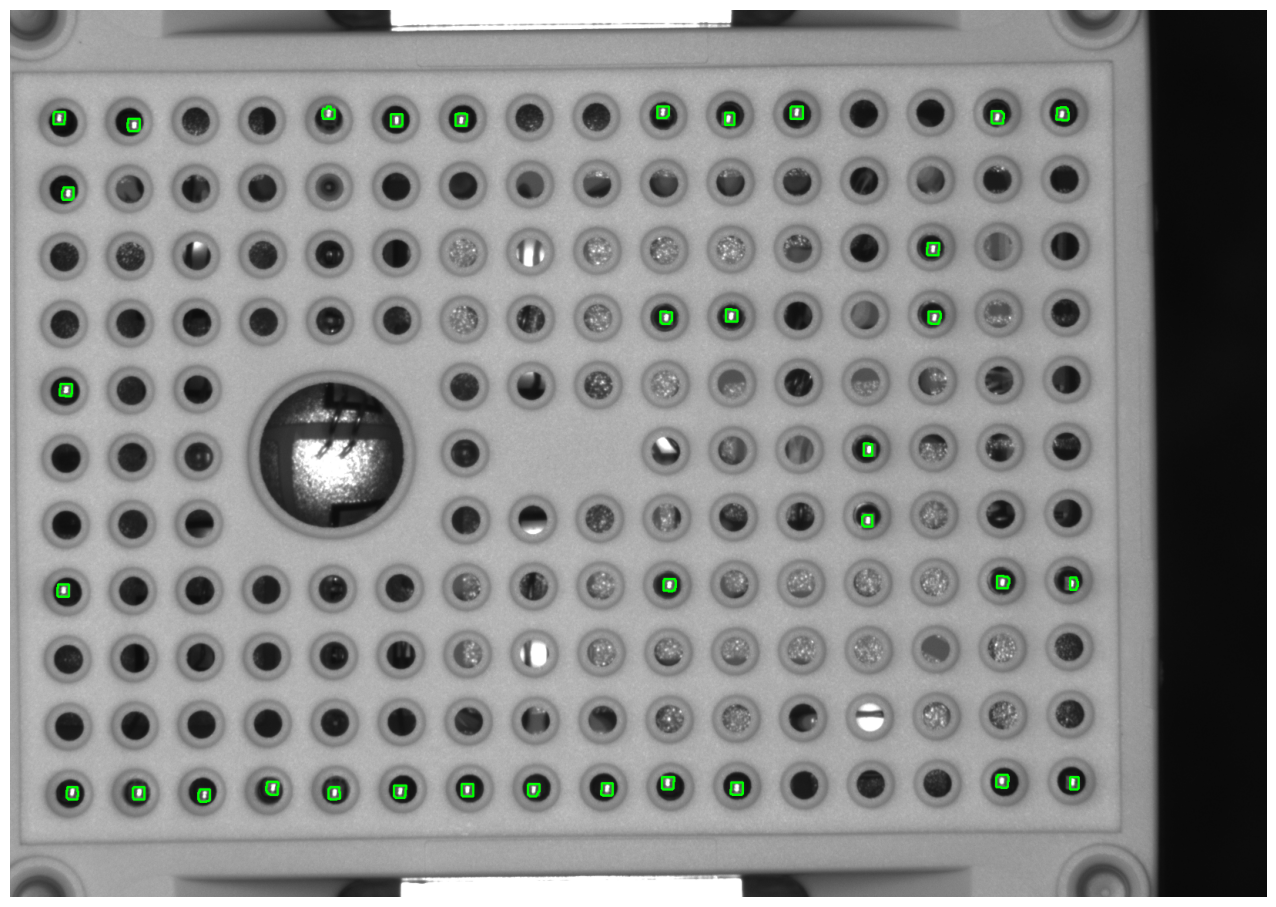

In [29]:
show_(overlay_mask_border_on_image_frm_img(
    im2_img,
    two_img_model_pred[0,0,:,:].cpu().numpy()*255
))

In [112]:
get_mask_stats(two_img_model_pred)

{'pin_cnt': 35,
 'max_pin_area': 253.0,
 'min_pin_area': 144.0,
 'mean_pin_area': np.float64(223.0857142857143),
 'median_pin_area': np.float64(231.5),
 'std_pin_area': np.float64(23.182963484385844),
 'pin_areas': [221.5,
  222.0,
  234.5,
  220.5,
  236.5,
  215.5,
  237.5,
  225.5,
  241.0,
  237.0,
  174.0,
  241.0,
  245.5,
  233.0,
  233.0,
  144.0,
  232.0,
  186.5,
  170.5,
  238.0,
  231.5,
  216.5,
  229.5,
  240.0,
  223.5,
  239.0,
  235.5,
  228.0,
  189.5,
  230.5,
  239.5,
  236.5,
  253.0,
  216.5,
  210.0]}

In [101]:
get_mask_stats(two_img_model_pred)

NameError: name 'get_mask_stats' is not defined

----
### 138 recipe 5149 seach pass fail



In [92]:
rec138_pairs[0]

('VFV4.9.0.3_2025060419170647_Out_138_Missing Lead_image2.png',
 'VFV4.9.0.3_2025060419170647_Out_138_Missing Lead_image1.png')

In [125]:
ds = InferenceTwoImageDataset(
    im1_files=[Path(im1_path,i[1]) for i in rec138_pairs],
    im2_files=[Path(im2_path,i[0]) for i in rec138_pairs],
    transform=None,
    img_size=(1152,1632),
    max_tries=2
)
dl = create_pin_dl(ds,batch_size=1,shuffle=False)

Dataset Statistics:
  Total image1 files: 5149
  Total image2 files: 5149
  Common paired files: 5149
  Missing pairs: 0


In [127]:
pred_list = []
for batch in tqdm(dl,total=len(dl)):
    print(batch['image'].shape)
    with torch.no_grad():
        print(batch['image'].shape)
        pred = two_img_model(batch['image'])
        pred_list.append(pred)

  0%|          | 0/5149 [00:00<?, ?it/s]

torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40
torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40
torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40
torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40
torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 40
torch.Size([1, 2, 1152, 1632])
torch.Size([1, 2, 1152, 1632])
 tiles has a shape of torch.Size([40, 1, 256, 256])
Tile size: torch.Size([1, 256, 256]) 
 num tiles: 4



import nbdev; nbdev.nbdev_export('000_three_channel_data_creation.ipynb')